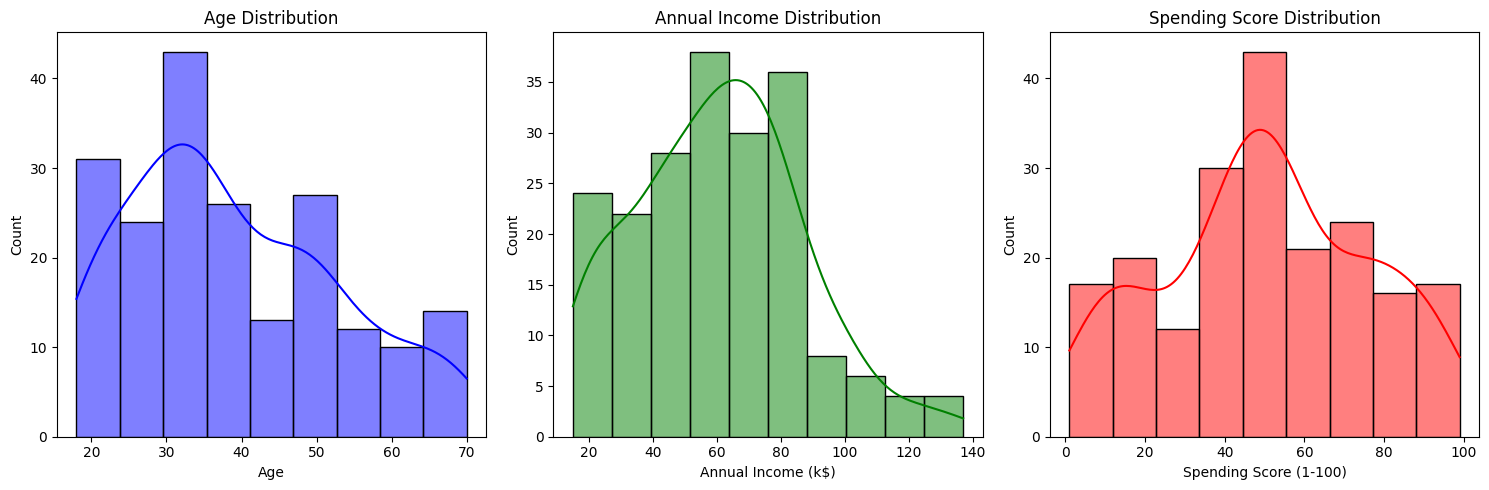

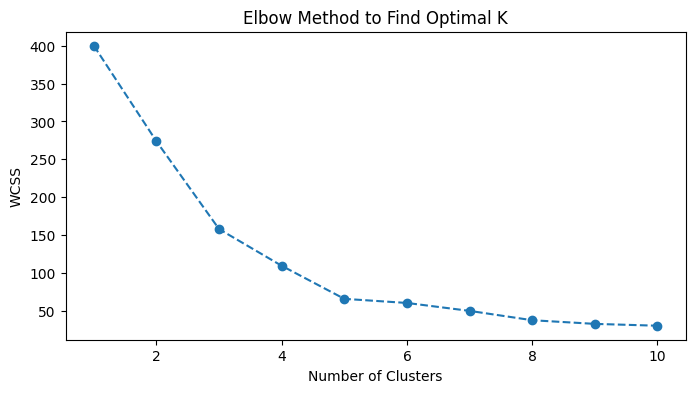

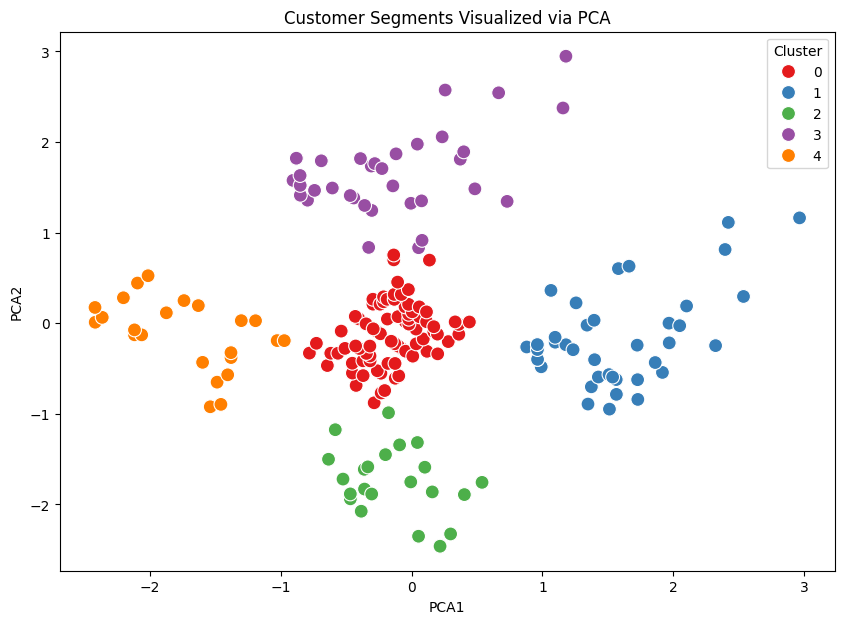

Cluster Characteristics:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- [Step 1: Dataset Description and Loading] --- [cite: 408]
# Load the dataset
df = pd.read_csv('Mall_Customers.csv')

# --- [Step 2: Data Cleaning and Preprocessing] --- [cite: 409]
# Drop CustomerID as it doesn't provide predictive value
df_clean = df.drop(['CustomerID'], axis=1)

# Rename 'Genre' to 'Gender' for better readability if necessary
df_clean.rename(columns={'Genre': 'Gender'}, inplace=True)

# Encode Gender for analysis
df_encoded = pd.get_dummies(df_clean, columns=['Gender'], drop_first=True)

# Select features for clustering (Annual Income and Spending Score are standard)
X = df_clean[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- [Step 3: Exploratory Data Analysis (EDA)] --- [cite: 410]
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_clean['Age'], kde=True, color='blue')
plt.title('Age Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df_clean['Annual Income (k$)'], kde=True, color='green')
plt.title('Annual Income Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df_clean['Spending Score (1-100)'], kde=True, color='red')
plt.title('Spending Score Distribution')

plt.tight_layout()
plt.show()

# --- [Step 4: Model Building - K-Means Clustering] --- [cite: 411]
# Use the Elbow Method to find the optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Find Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Applying K-Means with K=5 (optimal based on elbow) [cite: 352]
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# --- [Step 5: Visualizations (PCA)] --- [cite: 412]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_clean['PCA1'] = X_pca[:, 0]
df_clean['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_clean, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', s=100)
plt.title('Customer Segments Visualized via PCA')
plt.legend(title='Cluster')
plt.show()

# --- [Step 6: Final Conclusion with Insights] --- [cite: 413]
# Analyze the segments
segment_analysis = df_clean.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("Cluster Characteristics:")
print(segment_analysis)